In [11]:
!pip install emlearn

Defaulting to user installation because normal site-packages is not writeable


In [12]:
import numpy as np
import tensorflow as tf
from scipy import signal
import scipy.stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import os
import json
import re
import traceback

try:
    import emlearn
except ImportError:
    emlearn = None
    print("Import Emlearn failed !")


print(tf.__version__)
print("TensorFlow Keras version:", tf.keras.__version__)

import scipy
print("SciPy version:", scipy.__version__)

2.21.0
TensorFlow Keras version: 3.12.3
SciPy version: 1.15.3


In [13]:
CONFIG = {
    'axes': 3,
    'scale_axes': 0.00010017430721,
    'filter_type': 'low',
    'filter_cutoff': 26.05078125,
    'filter_order': 6,
    'fft_length': 64,
    'do_fft_overlap': False,
    'do_log': True,
    'sampling_freq': 57,
    'raw_samples_per_axis': 57,
}

In [14]:
FEATURES_PER_AXIS = 34  # 5 stats + 29 log10 FFT bins


def welch_max_hold(x, fs, fft_len, overlap=False):
    """Compute Welch max-hold power spectrum (non-overlapping windows)."""
    x = np.pad(x, (0, max(0, fft_len - len(x)))) if len(x) < fft_len else x
    n = len(x)
    num_bins = fft_len // 2 + 1
    psd_max = np.zeros(num_bins)
    stride = fft_len if not overlap else fft_len // 2
    window = np.hanning(fft_len)
    num_windows = (n - fft_len) // stride + 1
    for w in range(num_windows):
        start = w * stride
        seg = x[start:start + fft_len] * window
        fft_out = np.fft.rfft(seg)
        mag2 = (fft_out.real ** 2 + fft_out.imag ** 2) / (fft_len * np.sum(window ** 2))
        psd_max = np.maximum(psd_max, mag2)
    return psd_max


def extract_spec_features_axis(data_axis, config):
    fs = config['sampling_freq']
    fft_len = config['fft_length']
    x = data_axis.copy().astype(np.float64)

    # Butterworth lowpass filter
    if config['filter_type'] == 'low' and config['filter_order'] > 0:
        sos = signal.butter(config['filter_order'],
                            config['filter_cutoff'],
                            btype='low', fs=fs, output='sos')
        x = signal.sosfilt(sos, x)

    # Subtract mean
    x = x - np.mean(x)

    # Time-domain stats
    n = len(x)
    rms = float(np.sqrt(np.mean(x ** 2)))
    std = np.std(x, ddof=0)
    if std == 0:
        std = 1e-10
    skewness = float(np.mean(x ** 3) / (std ** 3))
    kurtosis = float(np.mean(x ** 4) / (std ** 4) - 3)

    # Welch max-hold spectrum
    psd = welch_max_hold(x, fs, fft_len, overlap=config['do_fft_overlap'])

    # Spectrum skewness and kurtosis (full spectrum, bins 0..32)
    psd_safe = np.maximum(psd, 1e-10)
    spec_skew = scipy.stats.skew(psd_safe)
    spec_skew = float(spec_skew) if np.isfinite(spec_skew) else 0.0
    spec_kurt = scipy.stats.kurtosis(psd_safe)
    spec_kurt = float(spec_kurt) if np.isfinite(spec_kurt) else 0.0

    # Log10 of bins [1..29] (skip DC, up to filter cutoff)
    cutoff_hz = config['filter_cutoff']
    bin_resolution = fs / fft_len
    stop_bin = int(np.floor(cutoff_hz / bin_resolution + 0.5)) + 1
    stop_bin = min(stop_bin, len(psd))
    start_bin = 1
    num_bins_used = stop_bin - start_bin  # should be 29

    log_bins = np.zeros(num_bins_used)
    for i in range(num_bins_used):
        val = max(psd[start_bin + i], 1e-10)
        log_bins[i] = float(np.log10(val))

    features = [rms, skewness, kurtosis, spec_skew, spec_kurt] + log_bins.tolist()
    return features


def extract_features(raw_window, config=CONFIG):
    x = raw_window * config['scale_axes']
    features = []
    for axis in range(config['axes']):
        feat = extract_spec_features_axis(x[:, axis], config)
        features.extend(feat)
    return np.array(features, dtype=np.float32)



2. DATASET PREPARATION 

In [15]:
def prepare_dataset(raw_data, labels, config=CONFIG):
    X = []
    for i in range(len(raw_data)):
        feat = extract_features(raw_data[i], config)
        X.append(feat)
    return np.array(X, dtype=np.float32), np.array(labels)


def load_json_data(dataset_path, config):
    all_raw_windows = []
    all_labels = []

    label_map = {}
    # Use training/info.labels to avoid extra labels from testing/root
    labels_filepath = os.path.join(dataset_path, 'training', 'info.labels')
    if not os.path.exists(labels_filepath):
        labels_filepath = os.path.join(dataset_path, 'info.labels')
    if not os.path.exists(labels_filepath):
        raise FileNotFoundError(f"info.labels not found at {labels_filepath}")
    with open(labels_filepath, 'r') as f:
        labels_info = json.load(f)

    unique_labels = sorted(list(set(item['label']['label'] for item in labels_info['files'] if 'label' in item and 'label' in item['label'])))
    unique_labels = [l for l in unique_labels if l != 'testing']
    for i, label_name in enumerate(unique_labels):
        label_map[label_name] = i

    if not unique_labels:
        raise ValueError("No unique labels found in info.labels. Check the JSON structure.")

    print(f"Label mapping: {label_map}")

    window_size = config['raw_samples_per_axis']
    stride = window_size // 2 

    subdirs = ['training']
    for subdir in subdirs:
        current_dir = os.path.join(dataset_path, subdir)
        if not os.path.isdir(current_dir):
            print(f"Warning: Directory '{current_dir}' not found. Skipping.")
            continue

        for filename in os.listdir(current_dir):
            if filename.endswith('.json'):
                filepath = os.path.join(current_dir, filename)
                try:
                    with open(filepath, 'r') as f:
                        data = json.load(f)

                    raw_recording_values = data['payload']['values']
                    raw_recording = np.array(raw_recording_values, dtype=np.float32)

                    # Get label from JSON directly, accessing nested 'label' field
                    label_name = data.get('label', {}).get('label')
                    if label_name is None:
                        # Fallback: Extract label from filename
                        match = re.match(r'([a-zA-Z0-9_\-]+)\.json', filename)
                        if match:
                            label_name = match.group(1)

                    if label_name not in label_map:
                        print(f"Warning: Label '{label_name}' from file '{filename}' not found in info.labels or could not be extracted. Skipping entire recording.")
                        continue

                    current_recording_length = raw_recording.shape[0]
                    if current_recording_length < window_size:
                        print(f"Warning: Recording in '{filename}' has length {current_recording_length}, which is less than expected window size {window_size}. Skipping.")
                        continue

                    # Extract windows from the raw recording
                    num_windows_in_recording = (current_recording_length - window_size) // stride + 1

                    for i in range(num_windows_in_recording):
                        start_idx = i * stride
                        end_idx = start_idx + window_size

                        # Ensure the window is exactly the expected size (116, 3)
                        window = raw_recording[start_idx:end_idx]
                        if window.shape == (window_size, config['axes']):
                            all_raw_windows.append(window)
                            all_labels.append(label_map[label_name])
                        else:
                            print(f"Warning: Extracted window from '{filename}' has shape {window.shape}, expected {(window_size, config['axes'])}. Skipping this window.")

                except KeyError as ke:
                    print(f"Error: Missing key in JSON file {filepath} (e.g., 'payload' or 'label'): {ke}. Skipping.")
                except Exception as e:
                    print(f"Error processing file {filepath}: {e}. Skipping.")

    print(f"Loaded {len(all_raw_windows)} valid windows after parsing and windowing.")
    if not all_raw_windows:
        raise ValueError("No data loaded from JSON files after windowing. Check paths, JSON structure, info.labels, and windowing logic.")

    return np.array(all_raw_windows, dtype=np.float32), np.array(all_labels, dtype=np.int32)

3. MODEL DEFINITION
Architecture (matching Edge Impulse v4 spectral analysis)
    Input:  (1, 102) int8   -- 34 features x 3 axes
    FC1:    20 units, ReLU   weights (20x102)
    FC2:    10 units, ReLU   weights (10x20)
    FC3:    6 units, Linear  weights (6x10)
    Softmax

Feature layout per axis (34 features):
    [0]  RMS, [1] Skewness, [2] Kurtosis
    [3]  Spectrum Skewness, [4] Spectrum Kurtosis
    [5..33] 29 log10 FFT bins (Welch max-hold, 64-pt FFT, no overlap)

In [16]:
def build_model(input_dim, num_classes=6):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(20, activation='relu', name='fc1'),
        tf.keras.layers.Dense(10, activation='relu', name='fc2'),
        tf.keras.layers.Dense(num_classes, activation='softmax', name='fc3'),
    ])
    return model

def train(X_train, y_train, X_val=None, y_val=None, epochs=50, num_classes=6):
    model = build_model(input_dim=X_train.shape[1], num_classes=num_classes)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
    ]

    val_data = (X_val, y_val) if X_val is not None else None
    history = model.fit(
        X_train, y_train,
        validation_data=val_data,
        epochs=epochs,
        batch_size=32,
        callbacks=callbacks,
        verbose=1,
    )
    return model, history


def fit_scaler(X_train):
    with np.errstate(divide='ignore', invalid='ignore'):
        scaler = StandardScaler(with_mean=True, with_std=True)
        scaler.fit(X_train)
    scaler.scale_[np.isinf(scaler.scale_) | np.isnan(scaler.scale_) | (scaler.scale_ == 0)] = 1.0
    return scaler


def representative_dataset(X_calib):
    for i in range(len(X_calib)):
        feat = X_calib[i]
        yield [feat.reshape(1, -1).astype(np.float32)]


def export_tflite(model, scaler, X_calib, config=CONFIG,
                  filename='model_quantized.tflite', input_dim=102):
    feature_input = tf.keras.layers.Input(shape=(input_dim,), name='feature_input')

    # StandardScaler uses (x - mean) / scale.
    mean = tf.constant(scaler.mean_, dtype=tf.float32)
    scale = tf.constant(scaler.scale_, dtype=tf.float32)
    norm_layer = tf.keras.layers.Lambda(
        lambda x: (x - mean) / scale,
        name='standard_scaler'
    )(feature_input)

    output = model(norm_layer)
    full_model = tf.keras.Model(inputs=feature_input, outputs=output)

    converter = tf.lite.TFLiteConverter.from_keras_model(full_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    def rep_gen():
        for i in range(min(200, len(X_calib))):
            feat = X_calib[i]
            yield [feat.reshape(1, -1).astype(np.float32)]
    converter.representative_dataset = rep_gen

    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
        tf.lite.OpsSet.SELECT_TF_OPS
    ]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    tflite_model = converter.convert()

    with open(filename, 'wb') as f:
        f.write(tflite_model)
    print(f"TFLite model saved: {filename} ({len(tflite_model)} bytes)")

    return tflite_model


# ============================================================
# 8. MAIN
# ============================================================

if __name__ == '__main__':
    print("=== Anomaly Detection Training Pipeline ===")
    print("\nLoading dataset: anomaly-detection-export from JSON files..." + os.getcwd())
    dataset_path = os.path.join(os.getcwd(), 'anomaly-detection-export')

    try:
        # Load data using the new JSON parsing function
        raw_data, labels = load_json_data(dataset_path, CONFIG)

        print(f"Raw data shape: {raw_data.shape}")
        print(f"Labels shape: {labels.shape}")

        # Extract features (18-dim)
        print("\nExtracting DSP features...")
        X, y = prepare_dataset(raw_data, labels, CONFIG)
        print(f"Extracted features shape (X): {X.shape}")
        print(f"Labels shape (y): {y.shape}")

        print("\nSplitting data into training and validation sets...")
        num_classes = len(np.unique(y))

        X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
        print(f"Training features shape: {X_tr.shape}")
        print(f"Validation features shape: {X_val.shape}")

        # Fit scaler
        print("\nFitting StandardScaler...")
        scaler = fit_scaler(X_tr)
        print("Transforming training and validation features...")
        X_tr_norm = scaler.transform(X_tr)
        X_val_norm = scaler.transform(X_val)
        print("Features normalized.")

        # Train
        print("\nStarting model training...")
        model, history = train(X_tr_norm, y_tr, X_val_norm, y_val, epochs=50, num_classes=num_classes)
        print("Model training complete.")

        print("\nExporting TFLite model...")
        tflite_model = export_tflite(model, scaler, X_tr, filename='anomaly_detection_model_quantized.tflite', input_dim=X.shape[1])

    except Exception as e:
        print(f"Error during data loading or processing: {e}")
        print("Skipping training and subsequent steps.")
        traceback.print_exc()

=== Anomaly Detection Training Pipeline ===

Loading dataset: anomaly-detection-export from JSON files.../home/tuan/workspace/embedded-edge-ai/application/sources/app/nn/trainning
Label mapping: {'down': 0, 'idle': 1, 'left': 2, 'right': 3, 'unknown': 4, 'up': 5}
Loaded 60 valid windows after parsing and windowing.
Raw data shape: (60, 57, 3)
Labels shape: (60,)

Extracting DSP features...
Extracted features shape (X): (60, 102)
Labels shape (y): (60,)

Splitting data into training and validation sets...
Training features shape: (48, 102)
Validation features shape: (12, 102)

Fitting StandardScaler...
Transforming training and validation features...
Features normalized.

Starting model training...
Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.1042 - loss: 2.0435 - val_accuracy: 0.0000e+00 - val_loss: 2.2917 - learning_rate: 5.0000e-04
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.1042 - loss: 1.9937 - val_accuracy: 0.0000e+00 - val_loss: 2.2349 - lear

INFO:tensorflow:Assets written to: /tmp/tmp0i1159lx/assets


Saved artifact at '/tmp/tmp0i1159lx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 102), dtype=tf.float32, name='feature_input')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  133653815166048: TensorSpec(shape=(102,), dtype=tf.float32, name=None)
  133653683512672: TensorSpec(shape=(102,), dtype=tf.float32, name=None)
  133653815179072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133653683514960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133653683513200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133653683513024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133653683504400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133653683515312: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model saved: anomaly_detection_model_quantized.tflite (6592 bytes)


/home/tuan/.local/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1784256417.454973 2086825 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1784256417.454983 2086825 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1784256417.455090 2086825 reader.cc:83] Reading SavedModel from: /tmp/tmp0i1159lx
I0000 00:00:1784256417.455393 2086825 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1784256417.455398 2086825 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp0i1159lx
I0000 00:00:1784256417.457978 2086825 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1784256417.474650 2086825 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp0i1159lx
I0000 00:00:1784256417.480679 2086825 loader.cc:471] SavedModel load for tags { serve }

In [17]:
def export_emlearn(model, filename='anomaly_detection_model.h', name='anomaly_model'):
    if emlearn is None:
        raise ImportError(
            "emlearn is not installed. Install it with `pip install emlearn`."
        )

    cmodel = emlearn.convert(model, method='inline')
    cmodel.save(file=filename, name=name)
    print(f"emlearn model saved: {filename}")
    return cmodel

print("\nExporting C/C++ model via emlearn...")
emlearn_model = export_emlearn(model, filename='anomaly_detection_model.h', name='anomaly_model')

print("\n/* Copy these scaler values to C++ */")
print("static const float NORM_MEAN[FEATURE_LEN] = {", ", ".join(f"{v:.4f}f" for v in scaler.mean_), "};")
print("static const float NORM_SCALE[FEATURE_LEN] = {", ", ".join(f"{v:.6f}f" for v in 1.0 / scaler.scale_), "};")
print(f"\nNum classes: {num_classes}")


Exporting C/C++ model via emlearn...
emlearn model saved: anomaly_detection_model.h

/* Copy these scaler values to C++ */
static const float NORM_MEAN[FEATURE_LEN] = { 0.0586f, 0.4755f, 5.5409f, 3.7967f, 14.5859f, -4.1574f, -4.7556f, -5.2411f, -5.7620f, -6.0528f, -6.1612f, -6.1891f, -6.3468f, -6.5078f, -6.5926f, -6.6836f, -6.7816f, -6.9130f, -6.8785f, -7.0390f, -7.2208f, -7.2761f, -7.2970f, -7.3757f, -7.5338f, -7.4643f, -7.4924f, -7.5741f, -7.5480f, -7.4518f, -7.3385f, -7.1376f, -6.7649f, -6.5661f, 0.0468f, 0.5964f, 3.4902f, 3.7023f, 13.7243f, -4.4533f, -4.6054f, -5.1303f, -5.6474f, -6.1638f, -6.2421f, -6.4006f, -6.8070f, -7.0178f, -7.0479f, -7.0998f, -7.3005f, -7.3457f, -7.3843f, -7.5963f, -7.6530f, -7.8540f, -7.8956f, -7.9056f, -8.0587f, -8.0023f, -7.8959f, -7.9568f, -7.9806f, -7.9766f, -7.9248f, -7.7791f, -7.7007f, -7.2788f, 0.1006f, -1.0255f, 9.4645f, 3.5938f, 12.7701f, -3.9725f, -4.3019f, -4.7267f, -5.3239f, -5.8861f, -5.9206f, -6.2117f, -6.5931f, -6.5662f, -6.6677f, -6.7609f, -

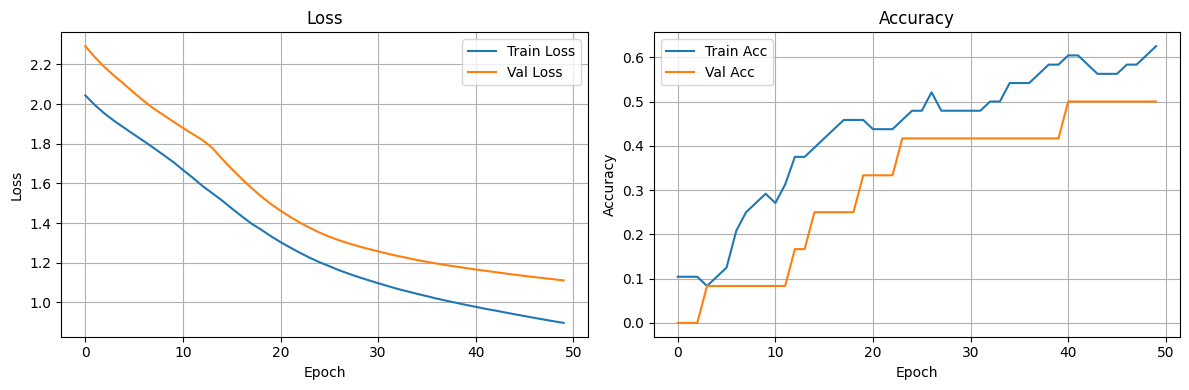

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Classification Report (Validation Set):
              precision    recall  f1-score   support

        down       0.00      0.00      0.00         0
        idle       0.67      1.00      0.80         2
        left       0.00      0.00      0.00         4
       right       0.25      0.50      0.33         2
     unknown       1.00      1.00      1.00         3
          up       0.00      0.00      0.00         1

    accuracy                           0.50        12
   macro avg       0.32      0.42      0.36        12
weighted avg       0.40      0.50      0.44        12



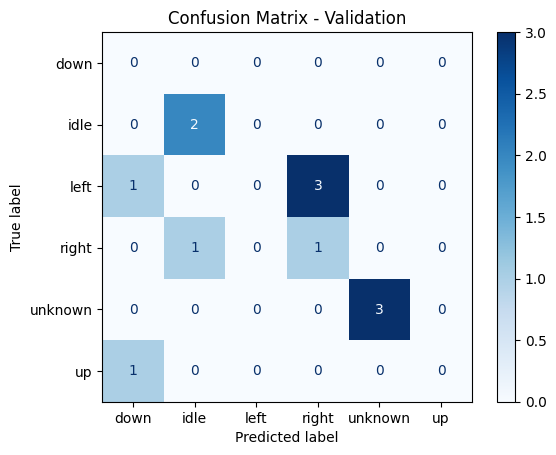

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_val_norm)
y_pred_classes = np.argmax(y_pred, axis=1)

target_names = ['down', 'idle', 'left', 'right', 'unknown', 'up']

print('Classification Report (Validation Set):')
print(classification_report(y_val, y_pred_classes, labels=list(range(num_classes)), target_names=target_names, zero_division=0))

cm = confusion_matrix(y_val, y_pred_classes, labels=list(range(num_classes)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Validation')
plt.savefig('confusion_matrix.png')
plt.show()

In [20]:
# ============================================================
# CONFIDENCE THRESHOLD ANALYSIS
# Run model on ALL data, analyze per-class softmax outputs
# ============================================================

labels_map = {0: 'down', 1: 'idle', 2: 'left', 3: 'right', 4: 'unknown', 5: 'up'}

# Normalize ALL data
X_all_norm = scaler.transform(X)

# Get softmax outputs for all samples
y_prob_all = model.predict(X_all_norm)

print("="*70)
print("CONFIDENCE THRESHOLD ANALYSIS")
print("="*70)
print(f"{'Class':<10} {'Count':<6} {'Min':<8} {'Mean':<8} {'Std':<8} {'Suggested':<10}")
print("-"*70)

suggested_conf = {}
for c in range(num_classes):
    mask = (y == c)
    count = mask.sum()
    if count == 0:
        print(f"{labels_map[c]:<10} {count:<6} (no samples)")
        suggested_conf[c] = 0.0
        continue
    probs_of_correct_class = y_prob_all[mask, c]
    min_prob = probs_of_correct_class.min()
    mean_prob = probs_of_correct_class.mean()
    std_prob = probs_of_correct_class.std()
    # Threshold = min - 1 std (but not below 0)
    threshold = max(0.0, min_prob - 1.0 * std_prob)
    suggested_conf[c] = threshold
    print(f"{labels_map[c]:<10} {count:<6} {min_prob:<8.4f} {mean_prob:<8.4f} {std_prob:<8.4f} {threshold:<10.4f}")

print("="*70)
print("\nSuggested confidence thresholds (for app.cpp):")
print("  AnomalyConfidence_t conf = {0.0f};")
for c in range(num_classes):
    print(f"  conf.{labels_map[c]} = {suggested_conf[c]:.4f}f;")

# Also show: what if we use mean - 2*std?
print("\n--- Alternative: mean - 2*std (more conservative) ---")
for c in range(num_classes):
    mask = (y == c)
    if mask.sum() == 0:
        continue
    probs = y_prob_all[mask, c]
    threshold = max(0.0, probs.mean() - 2.0 * probs.std())
    print(f"  conf.{labels_map[c]} = {threshold:.4f}f;")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
CONFIDENCE THRESHOLD ANALYSIS
Class      Count  Min      Mean     Std      Suggested 
----------------------------------------------------------------------
down       8      0.2500   0.3353   0.0719   0.1782    
idle       14     0.9207   0.9565   0.0195   0.9012    
left       7      0.1203   0.1455   0.0143   0.1060    
right      9      0.1445   0.3245   0.0864   0.0581    
unknown    11     0.1187   0.5518   0.1783   0.0000    
up         11     0.1900   0.2682   0.0745   0.1155    

Suggested confidence thresholds (for app.cpp):
  AnomalyConfidence_t conf = {0.0f};
  conf.down = 0.1782f;
  conf.idle = 0.9012f;
  conf.left = 0.1060f;
  conf.right = 0.0581f;
  conf.unknown = 0.0000f;
  conf.up = 0.1155f;

--- Alternative: mean - 2*std (more conservative) ---
  conf.down = 0.1915f;
  conf.idle = 0.9176f;
  conf.left = 0.1170f;
  conf.right = 0.1517f;
  conf.unknown = 0.1951f;
  conf.up = 0.1192f;
